In [91]:
from pathlib import Path
from matplotlib import pyplot as plt
import yaml
import pickle

  You can safely remove it manually.

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 63.0 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.9.2
    Uninstalling matplotlib-3.9.2:
      Successfully uninstalled matplotlib-3.9.2


In [92]:
BASE = Path.cwd().parents[1] / "results" 
PATH_LOCAL_RCPARAMS = Path.cwd().parents[1] / "config" / "rc_params.yml"

In [93]:
SUBFIGS = {
    "figure_3a": "ablation_relative/Inductive_AUPRC_00.pickle",
    "figure_3b": "ablation_relative/Inductive_AUPRC_50.pickle",
    "figure_2a": (
        "literature_methods"
        "/TT/all_datasets"
        "/critical_difference_diagrams"
        "/AUPRC (Inductive).pickle"
    ),
    "figure_2b": (
        "literature_methods"
        "/TT/all_datasets"
        "/critical_difference_diagrams"
        "/AUROC (Inductive).pickle"
    ),
    "figure_5a": "leaf_size/Inductive_AUPRC_00.pickle",
    "figure_5b": "leaf_size/Inductive_AUROC_00.pickle",
    "figure_6a": (
        "number_of_trees/Inductive_AUPRC_0_BICTR_Oxytrees.pickle"
    ),
    "figure_6b": (
        "number_of_trees/Inductive_AUROC_0_BICTR_Oxytrees.pickle"
    ),
    "figure_4a": (
        "empirical_complexity_plots/empirical_complexity_fit.pickle"
    ),
    "figure_4b": (
        "empirical_complexity_plots/empirical_complexity_leaf_assign.pickle"
    ),
}

In [94]:
plt.rcParams.update(plt.rcParamsDefault)
renaming = yaml.safe_load(PATH_NAME_REPLACEMENTS_CONFIG.read_text())
plt.rcParams.update(yaml.safe_load(PATH_LOCAL_RCPARAMS.read_text()))
plt.rcParams.update(
    {
        "legend.fontsize": 5,
    }
)

# \textwidth and \columnwidth in AAAI layout (printed by LaTeX)
TEXT_WIDTH = 7.00137
COLUMN_WIDTH = 3.31314
HALF_COLUMN_WIDTH = COLUMN_WIDTH / 2 - 0.001  # Some small margin

In [105]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines
import matplotlib.collections as mcollections

import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.text as mtext
import matplotlib.image as mimage
import matplotlib.collections as mcoll

def clone_artists(ax_src, ax_dst):
    # --- Lines ---
    for line in ax_src.get_lines():
        ax_dst.plot(
            line.get_xdata(),
            line.get_ydata(),
            linestyle=line.get_linestyle(),
            linewidth=line.get_linewidth(),
            marker=line.get_marker(),
            markersize=line.get_markersize(),
            color=line.get_color(),
            label=line.get_label()
        )

    # --- Patches (bars etc.) ---
    for patch in ax_src.patches:
        if isinstance(patch, mpatches.Rectangle):
            new = mpatches.Rectangle(
                patch.get_xy(),
                patch.get_width(),
                patch.get_height(),
                angle=patch.get_angle(),
                edgecolor=patch.get_edgecolor(),
                facecolor=patch.get_facecolor(),
                linewidth=patch.get_linewidth(),
                linestyle=patch.get_linestyle()
            )
            ax_dst.add_patch(new)

    # --- Collections (scatter) ---
    for coll in ax_src.collections:
        if isinstance(coll, mcoll.PathCollection):
            ax_dst.scatter(
                coll.get_offsets()[:,0],
                coll.get_offsets()[:,1],
                s=coll.get_sizes(),
                c=coll.get_facecolors(),
                marker=coll.get_paths()[0],
                label=coll.get_label()
            )

    # --- Text (labels, titles) ---
    for txt in ax_src.texts:
        ax_dst.text(
            txt.get_position()[0],
            txt.get_position()[1],
            txt.get_text(),
            fontsize=txt.get_fontsize(),
            fontweight=txt.get_fontweight(),
            ha=txt.get_ha(),
            va=txt.get_va()
        )

    # --- Labels & title ---
    ax_dst.set_title(ax_src.get_title())
    ax_dst.set_xlabel(ax_src.get_xlabel())
    ax_dst.set_ylabel(ax_src.get_ylabel())

    # --- Legend ---
    legend = ax_src.get_legend()
    if legend:
        ax_dst.legend(loc=legend._loc)


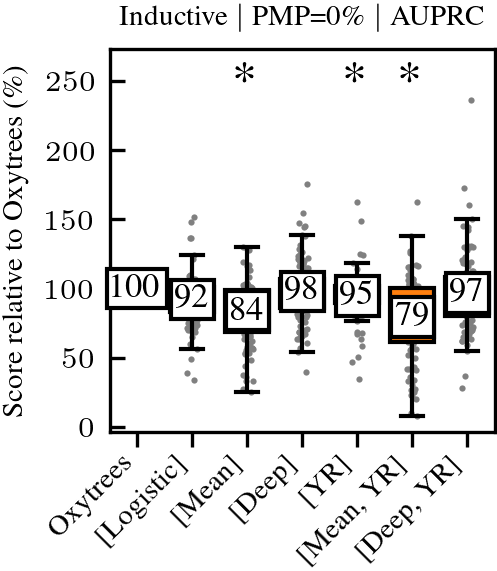

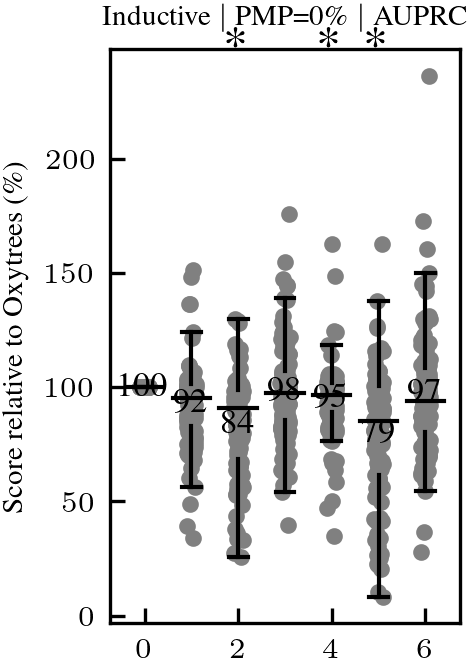

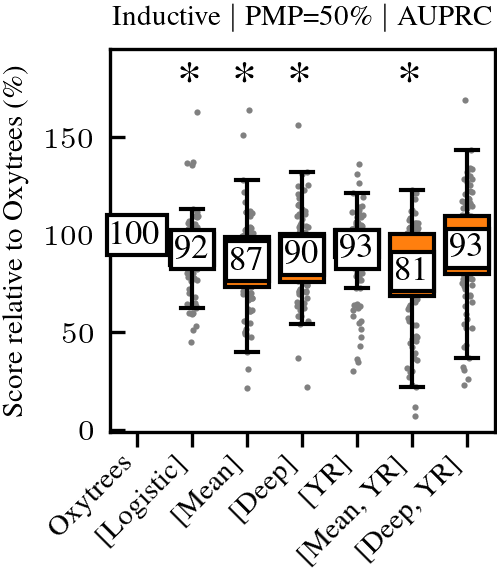

In [106]:
# Figure 3
from matplotlib.gridspec import GridSpec, SubplotSpec

fig = plt.figure(figsize=(COLUMN_WIDTH, COLUMN_WIDTH * 0.75))

with open(BASE / SUBFIGS["figure_3a"], "rb") as f:
    fig_3a = pickle.load(f)
with open(BASE / SUBFIGS["figure_3b"], "rb") as f:
    fig_3b = pickle.load(f)

subplot1 = fig.add_subplot(1, 2, 1)
old_axes_3a = fig_3a.axes[0]

clone_artists(old_axes_3a, subplot1)

display(fig_3a)

# fig_3a.delaxes(old_axes_3a)
for artist in old_axes_3a.get_children():
    artist.figure = fig

display(fig)
plt.close(fig_3a)

old_axes_3b = fig_3b.axes[0]
display(fig_3b)
fig_3b.delaxes(old_axes_3b)
plt.close(fig_3b)